In [1]:
# Import necessary packages
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from matplotlib.gridspec import GridSpec
try:
    from community import community_louvain
    HAVE_LOUVAIN = True
except Exception:
    HAVE_LOUVAIN = False

In [2]:
# Data paths and analysis parameters
# Here the data is the top protein-TRN and protein-drug combos, annotated with cluster (RFI) ID
TRN_FILE = Path("data/top_protein_pathway_combos_clusterid.csv")
DRUG_FILE = Path("data/top_protein_drug_combos_clusterid.csv")

TRN_SCORE_THRESHOLD = 0.6
DRUG_SCORE_THRESHOLD = 1.0

MAX_PROTEIN_DEGREE = 300
MAX_TRN_DEGREE = 900
MAX_DRUG_DEGREE = 900

In [3]:
# Set plotting parameters
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

In [4]:
# Helper functions
def normalize_columns(df):
    """Standardize common column names without changing the original file on disk."""
    df = df.copy()
    if "Unnamed: 0" in df.columns and "protein" not in df.columns:
        df = df.rename(columns={"Unnamed: 0": "protein"})
    if df.index.name is not None and "protein" not in df.columns:
        df = df.reset_index().rename(columns={df.index.name: "protein"})
    return df


def read_trn_scores(path=TRN_FILE):
    """Read protein-TRN Gi* scores."""
    df = pd.read_csv(path, index_col=0)
    df = df.reset_index().rename(columns={"index": "protein"})
    df = df.rename(columns={"pathway": "trn"})
    required = {"protein", "trn", "score"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"TRN file is missing required columns: {missing}")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    return df.dropna(subset=["protein", "trn", "score"])


def read_drug_scores(path=DRUG_FILE):
    """Read protein-drug association scores."""
    df = pd.read_csv(path)
    df = normalize_columns(df)
    required = {"protein", "drug", "score"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Drug file is missing required columns: {missing}")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    return df.dropna(subset=["protein", "drug", "score"])


def build_bipartite_graph(
    df,
    left_col,
    right_col,
    score_col="score",
    left_type="protein",
    right_type="feature",
    score_threshold=None,
    use_abs_for_threshold=True,
):
    """Build a weighted bipartite graph from a long-form score table."""
    d = df[[left_col, right_col, score_col]].dropna().copy()
    d[left_col] = d[left_col].astype(str)
    d[right_col] = d[right_col].astype(str)
    d[score_col] = pd.to_numeric(d[score_col], errors="coerce")
    d = d.dropna(subset=[score_col])
    d = d[d[left_col] != d[right_col]]

    if score_threshold is not None:
        if use_abs_for_threshold:
            d = d[d[score_col].abs() >= score_threshold]
        else:
            d = d[d[score_col] >= score_threshold]

    G = nx.Graph()
    for n in d[left_col].unique():
        G.add_node(n, node_type=left_type, bipartite=0)
    for n in d[right_col].unique():
        G.add_node(n, node_type=right_type, bipartite=1)

    for row in d.itertuples(index=False):
        left = getattr(row, left_col)
        right = getattr(row, right_col)
        score = float(getattr(row, score_col))
        G.add_edge(left, right, score=score, weight=abs(score), weight_abs=abs(score))

    return G, d


def filter_bipartite_by_degree(
    G,
    max_left_degree=300,
    max_right_degree=900,
    left_type="protein",
    right_type="feature",
    drop_isolates=True,
):
    """Remove extreme high-degree background nodes and optionally drop isolates."""
    keep = []
    for n, a in G.nodes(data=True):
        node_type = a.get("node_type")
        deg = G.degree(n)
        if node_type == left_type and deg <= max_left_degree:
            keep.append(n)
        elif node_type == right_type and deg <= max_right_degree:
            keep.append(n)

    Gf = G.subgraph(keep).copy()
    if drop_isolates:
        Gf.remove_nodes_from(list(nx.isolates(Gf)))
    return Gf


def summarize_protein_nodes(G, feature_type):
    """Return degree and amplitude summaries for protein nodes in a bipartite graph."""
    rows = []
    for p, a in G.nodes(data=True):
        if a.get("node_type") != "protein":
            continue

        edges = list(G.edges(p, data=True))
        if not edges:
            continue

        vals = np.array([abs(d["score"]) for _, _, d in edges], dtype=float)
        rows.append({
            "protein": p,
            f"{feature_type}_degree": G.degree(p),
            f"mean_abs_{feature_type}": float(vals.mean()),
            f"p95_abs_{feature_type}": float(np.percentile(vals, 95)),
            f"max_abs_{feature_type}": float(vals.max()),
        })

    return pd.DataFrame(rows)


def feature_jaccard_matrix(G, feature_type):
    """Compute feature-feature Jaccard similarity based on shared protein neighbors."""
    features = [n for n, a in G.nodes(data=True) if a.get("node_type") == feature_type]
    feature_to_proteins = {
        f: {nbr for nbr in G.neighbors(f) if G.nodes[nbr].get("node_type") == "protein"}
        for f in features
    }

    J = np.zeros((len(features), len(features)), dtype=float)
    for i, fi in enumerate(features):
        A = feature_to_proteins[fi]
        for j in range(i, len(features)):
            B = feature_to_proteins[features[j]]
            union = len(A | B)
            sim = len(A & B) / union if union else 0.0
            J[i, j] = sim
            J[j, i] = sim

    return features, J, feature_to_proteins


def similarity_graph(features, J, percentile=95):
    """Threshold a Jaccard matrix and return a feature similarity graph."""
    off = J[np.triu_indices_from(J, k=1)]
    off_nonzero = off[off > 0]
    threshold = float(np.percentile(off_nonzero, percentile)) if len(off_nonzero) else 0.0

    H = nx.Graph()
    H.add_nodes_from(features)
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            if J[i, j] >= threshold:
                H.add_edge(features[i], features[j], weight=float(J[i, j]))

    return H, threshold


def detect_modules(H):
    """Detect modules with Louvain when available, otherwise use connected components."""
    if HAVE_LOUVAIN and H.number_of_edges() > 0:
        part = community_louvain.best_partition(H, weight="weight", random_state=1)
    else:
        part = {}
        for i, comp in enumerate(nx.connected_components(H)):
            for n in comp:
                part[n] = i

    return pd.DataFrame({"feature": list(part.keys()), "module": list(part.values())})


def ordered_matrix(features, J, module_df, feature_col="feature"):
    """Order a similarity matrix by module labels."""
    mod_map = dict(zip(module_df[feature_col], module_df["module"]))
    order = sorted(range(len(features)), key=lambda i: (mod_map.get(features[i], 999), features[i]))
    return J[np.ix_(order, order)], [features[i] for i in order], [mod_map.get(features[i], -1) for i in order]


def classify_proteins(prot_df, degree_col="trn_degree"):
    """Add specific, intermediate, and pleiotropic labels by degree."""
    out = prot_df.copy()
    q25 = out[degree_col].quantile(0.25)
    q90 = out[degree_col].quantile(0.90)

    out["class"] = "intermediate"
    out.loc[out[degree_col] <= q25, "class"] = "specific"
    out.loc[out[degree_col] >= q90, "class"] = "pleiotropic"
    return out, q25, q90


def save_panel(fig, name):
    """Save a panel as SVG and PDF."""
    fig.savefig(OUTDIR / f"{name}.svg", bbox_inches="tight")
    fig.savefig(OUTDIR / f"{name}.pdf", bbox_inches="tight")


In [5]:
# Read data
trn_scores = read_trn_scores(TRN_FILE)
drug_scores = read_drug_scores(DRUG_FILE)

In [6]:
# Build TRN and drug networks within notebook for graphing
G_trn_raw, trn_edges = build_bipartite_graph(
    trn_scores,
    left_col="protein",
    right_col="trn",
    left_type="protein",
    right_type="trn",
    score_threshold=TRN_SCORE_THRESHOLD,
    use_abs_for_threshold=True,
)

G_trn = filter_bipartite_by_degree(
    G_trn_raw,
    max_left_degree=MAX_PROTEIN_DEGREE,
    max_right_degree=MAX_TRN_DEGREE,
    left_type="protein",
    right_type="trn",
)

G_drug_raw, drug_edges = build_bipartite_graph(
    drug_scores,
    left_col="protein",
    right_col="drug",
    left_type="protein",
    right_type="drug",
    score_threshold=DRUG_SCORE_THRESHOLD,
    use_abs_for_threshold=True,
)

G_drug = filter_bipartite_by_degree(
    G_drug_raw,
    max_left_degree=MAX_PROTEIN_DEGREE,
    max_right_degree=MAX_DRUG_DEGREE,
    left_type="protein",
    right_type="drug",
)

In [7]:
# Derived tables used by multiple panels
# Summarize protein connectivity in TRN and drug graphs
trn_prot = summarize_protein_nodes(G_trn, "trn")
drug_prot = summarize_protein_nodes(G_drug, "drug")

# Merge TRN and drug summaries (keep all TRN proteins)
prot_df = trn_prot.merge(
    drug_prot[["protein", "drug_degree", "p95_abs_drug", "max_abs_drug"]],
    on="protein",
    how="left",
)

# Fill missing drug values (proteins with no drug associations)
prot_df["drug_degree"] = prot_df["drug_degree"].fillna(0).astype(int)
prot_df["p95_abs_drug"] = prot_df["p95_abs_drug"].fillna(0)
prot_df["max_abs_drug"] = prot_df["max_abs_drug"].fillna(0)

# Flag whether a protein is linked to any drug
prot_df["drug_linked"] = prot_df["drug_degree"] > 0

# Classify proteins by TRN connectivity (returns percentile cutoffs)
prot_df, trn_p25, trn_p90 = classify_proteins(
    prot_df,
    degree_col="trn_degree"
)

# Compute TRN–TRN similarity via Jaccard over shared proteins
trn_features, J_trn, trn_to_proteins = feature_jaccard_matrix(G_trn, "trn")

# Build similarity graph using top 5% Jaccard edges
H_trn, trn_jaccard_threshold = similarity_graph(
    trn_features,
    J_trn,
    percentile=95
)

# Detect TRN modules and order matrix for visualization
trn_modules = detect_modules(H_trn).rename(columns={"feature": "trn"})
J_trn_ord, trns_ord, trn_mods_ord = ordered_matrix(
    trn_features,
    J_trn,
    trn_modules,
    feature_col="trn"
)

# Compute drug–drug similarity via shared protein targets
drug_features, J_drug, drug_to_proteins = feature_jaccard_matrix(G_drug, "drug")

# Build similarity graph (top 5% edges) and detect modules
H_drug, drug_jaccard_threshold = similarity_graph(
    drug_features,
    J_drug,
    percentile=95
)
drug_modules = detect_modules(H_drug).rename(columns={"feature": "drug"})

# Order drug similarity matrix for plotting
J_drug_ord, drugs_ord, drug_mods_ord = ordered_matrix(
    drug_features,
    J_drug,
    drug_modules,
    feature_col="drug"
)

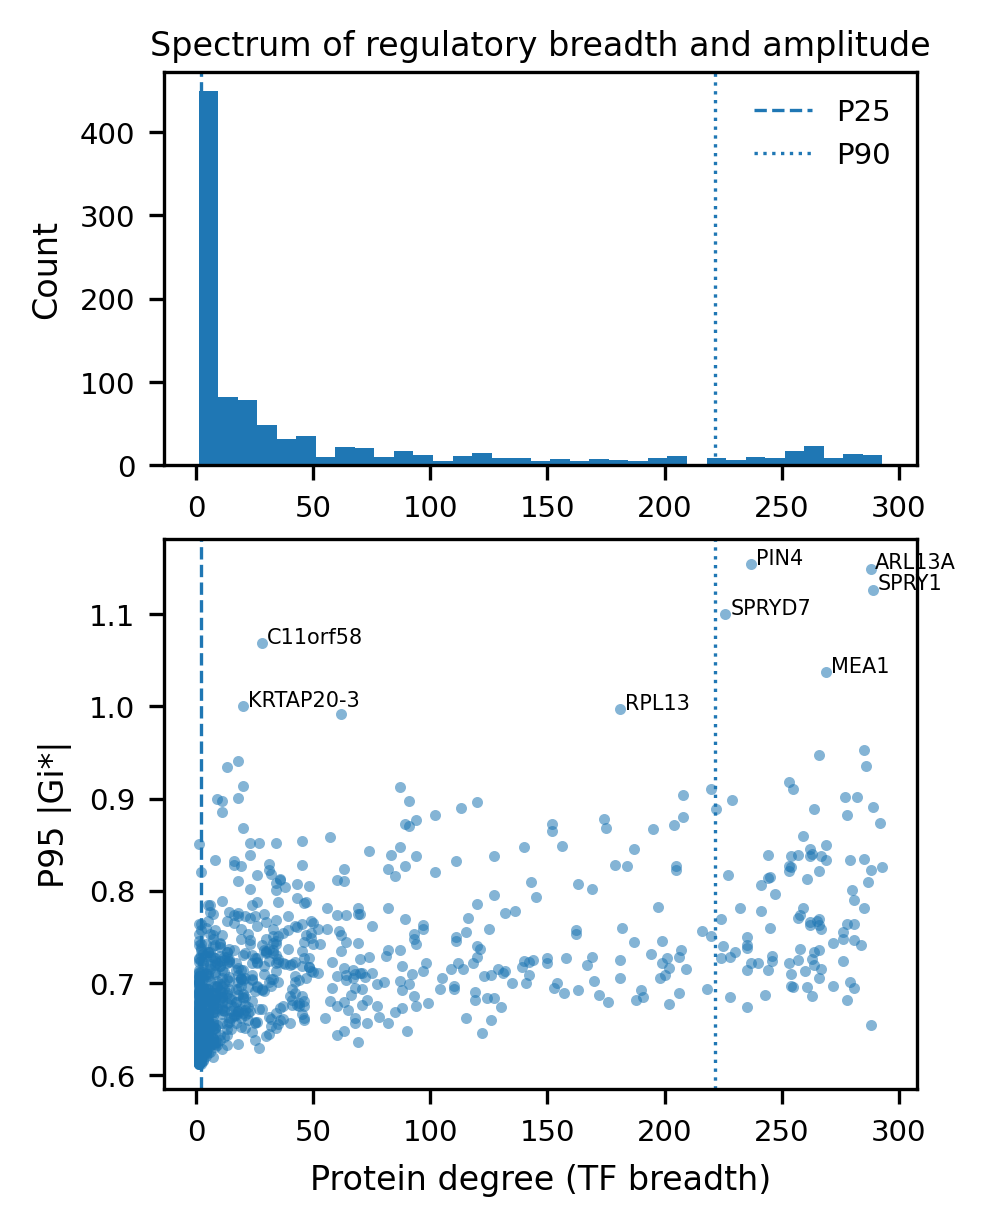

In [8]:
# Panel B: regulatory breadth histogram and breadth–amplitude scatter

# Create stacked histogram (top) and scatter (bottom)
fig, (ax_hist, ax_scatter) = plt.subplots(
    2, 1,
    figsize=(3.2, 4.0),
    gridspec_kw={"height_ratios": [1, 1.4]},
)

# Extract TRN degree (regulatory breadth)
deg_vals = prot_df["trn_degree"]

# Histogram of protein regulatory breadth
ax_hist.hist(deg_vals, bins=35)

# Mark 25th and 90th percentile thresholds
ax_hist.axvline(trn_p25, linestyle="--", linewidth=0.8, label="P25")
ax_hist.axvline(trn_p90, linestyle=":", linewidth=0.8, label="P90")

ax_hist.set_ylabel("Count")
ax_hist.set_title("Spectrum of regulatory breadth and amplitude", pad=4)
ax_hist.legend(frameon=False)


# Scatter: breadth (degree) vs TRN amplitude (P95 |Gi*|)
ax_scatter.scatter(
    prot_df["trn_degree"],
    prot_df["p95_abs_trn"],
    s=7,
    alpha=0.55,
    linewidths=0,
)

# Add same percentile cutoffs for reference
ax_scatter.axvline(trn_p25, linestyle="--", linewidth=0.8)
ax_scatter.axvline(trn_p90, linestyle=":", linewidth=0.8)

ax_scatter.set_xlabel("Protein degree (TF breadth)")
ax_scatter.set_ylabel("P95 |Gi*|")


# Label top proteins by combined amplitude + breadth
top_labels = prot_df.sort_values(
    ["p95_abs_trn", "trn_degree"],
    ascending=False
).head(8)

for _, row in top_labels.iterrows():
    ax_scatter.text(
        row["trn_degree"] + 2,
        row["p95_abs_trn"],
        row["protein"],
        fontsize=5
    )

# Show plot
plt.tight_layout(pad=0.5)
plt.show()

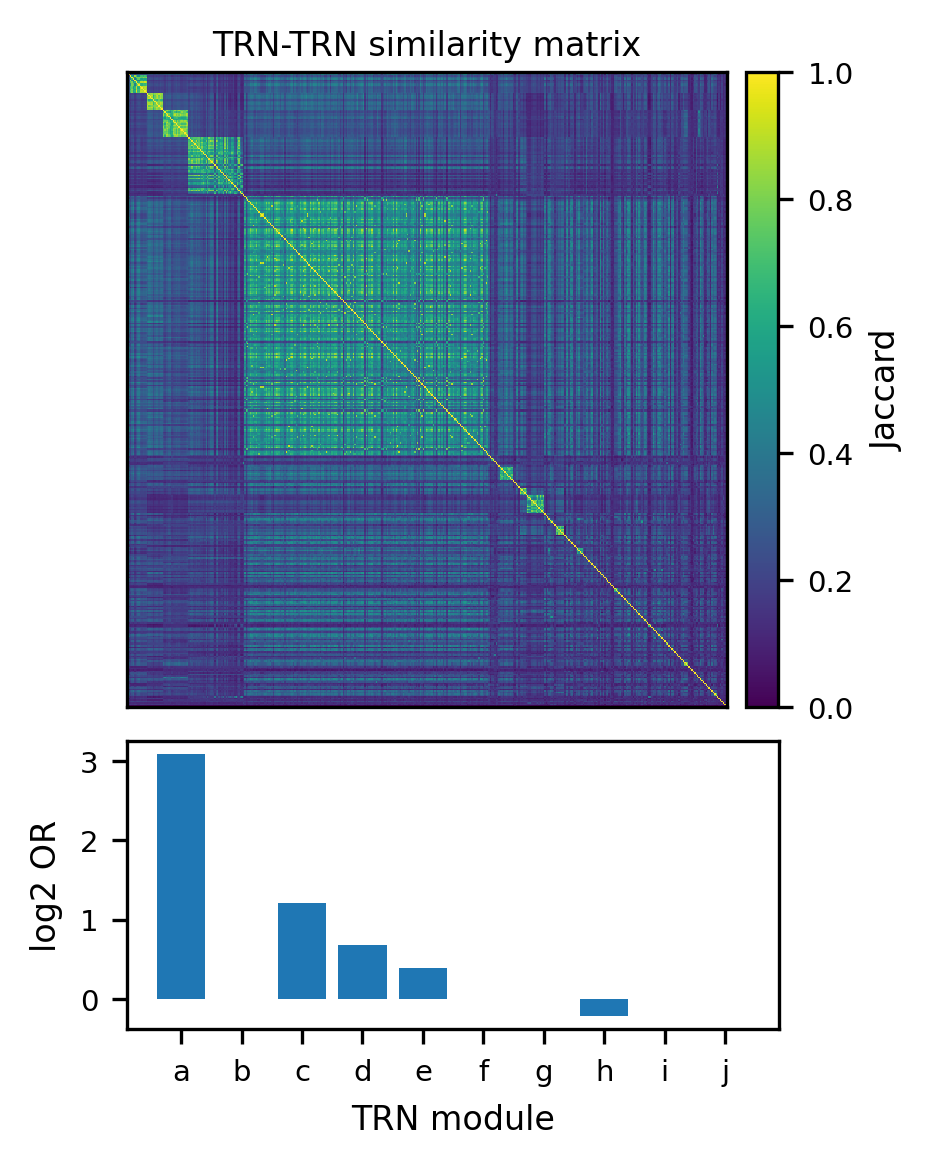

In [9]:
# Panel C: TRN similarity matrix + module enrichment

# Heatmap (TRN–TRN Jaccard similarity)
fig, (ax_heat, ax_bar) = plt.subplots(
    2, 1,
    figsize=(3.0, 3.8),
    gridspec_kw={"height_ratios": [2.2, 1]},
)

im = ax_heat.imshow(J_trn_ord, aspect="auto", interpolation="nearest")
ax_heat.set_xticks([])
ax_heat.set_yticks([])
ax_heat.set_title("TRN-TRN similarity matrix", pad=4)

cbar = fig.colorbar(im, ax=ax_heat, fraction=0.05, pad=0.03)
cbar.set_label("Jaccard", fontsize=8)


# Map TRNs → modules
trn_mod_map = dict(zip(trn_modules["trn"], trn_modules["module"]))

# Map proteins → their TRNs in the graph
prot_to_trns = {
    p: {n for n in G_trn.neighbors(p) if G_trn.nodes[n].get("node_type") == "trn"}
    for p in prot_df["protein"]
    if p in G_trn
}

# Collect TRNs associated with a protein class
def trns_for_class(class_name):
    proteins = prot_df.loc[prot_df["class"] == class_name, "protein"]
    out = set()
    for p in proteins:
        out.update(prot_to_trns.get(p, set()))
    return out

# TRNs linked to pleiotropic vs specific proteins
pleio_trns = trns_for_class("pleiotropic")
specific_trns = trns_for_class("specific")


# Enrichment per module (Fisher’s exact test)
rows = []
for m in sorted(set(trn_mod_map.values())):
    module_trns = {t for t, mod in trn_mod_map.items() if mod == m}

    a = len(module_trns & pleio_trns)
    c = len(module_trns & specific_trns)
    b = max(len(pleio_trns) - a, 0)
    d = max(len(specific_trns) - c, 0)

    odds, pval = fisher_exact([[a, b], [c, d]], alternative="greater")

    rows.append({
        "module": m,
        "log2_or": np.log2(odds) if np.isfinite(odds) and odds > 0 else np.nan,
        "p_value": pval
    })

# Take top enriched modules and label a, b, c, ...
module_enrich = pd.DataFrame(rows).sort_values("p_value")
plot_enrich = module_enrich.head(10).copy()
plot_enrich["label"] = [chr(97 + i) for i in range(len(plot_enrich))]

# Bar plot of enrichment (log2 odds ratio)
ax_bar.bar(plot_enrich["label"], plot_enrich["log2_or"].fillna(0))
ax_bar.set_xlabel("TRN module")
ax_bar.set_ylabel("log2 OR")

# Show plot
plt.tight_layout(pad=0.5)
plt.show()

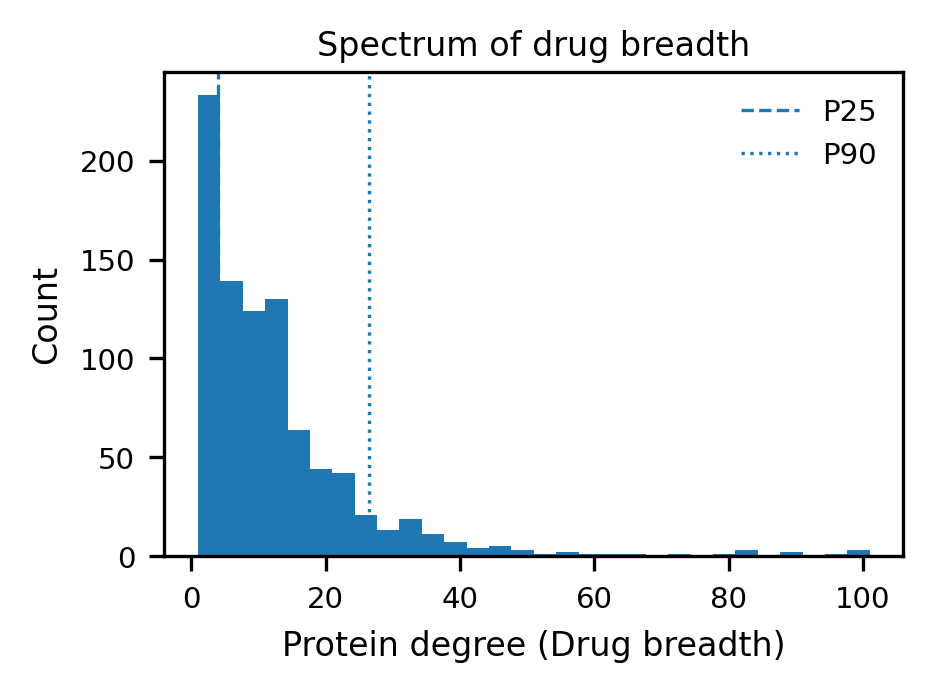

In [10]:
# Panel F: drug breadth histogram

# Compute percentile thresholds
drug_p25 = drug_prot["drug_degree"].quantile(0.25)
drug_p90 = drug_prot["drug_degree"].quantile(0.90)

fig, ax = plt.subplots(figsize=(3.0, 2.2))

# Histogram of drug connectivity per protein
ax.hist(drug_prot["drug_degree"], bins=30)

# Mark percentile cutoffs
ax.axvline(drug_p25, linestyle="--", linewidth=0.8, label="P25")
ax.axvline(drug_p90, linestyle=":", linewidth=0.8, label="P90")

ax.set_xlabel("Protein degree (Drug breadth)")
ax.set_ylabel("Count")
ax.set_title("Spectrum of drug breadth", pad=4)
ax.legend(frameon=False)

# Show plot
plt.tight_layout(pad=0.4)
plt.show()

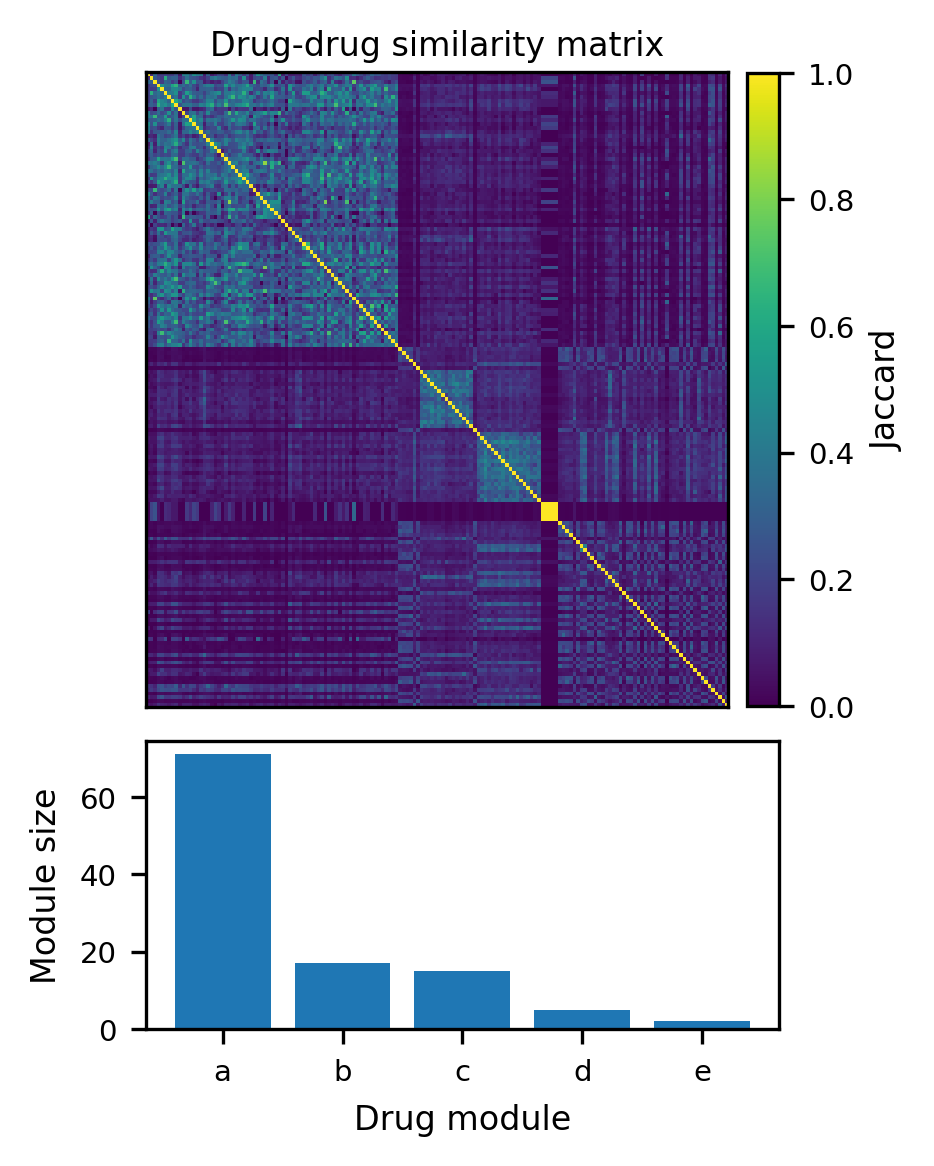

In [11]:
# Panel G: drug similarity matrix + module size summary

fig, (ax_heat, ax_bar) = plt.subplots(
    2, 1,
    figsize=(3.0, 3.8),
    gridspec_kw={"height_ratios": [2.2, 1]},
)

# Heatmap of drug–drug Jaccard similarity
im = ax_heat.imshow(J_drug_ord, aspect="auto", interpolation="nearest")
ax_heat.set_xticks([])
ax_heat.set_yticks([])
ax_heat.set_title("Drug-drug similarity matrix", pad=4)

cbar = fig.colorbar(im, ax=ax_heat, fraction=0.05, pad=0.03)
cbar.set_label("Jaccard", fontsize=8)


# Map drugs → modules and count module sizes
drug_mod_map = dict(zip(drug_modules["drug"], drug_modules["module"]))
drug_module_sizes = drug_modules["module"].value_counts().sort_values(ascending=False)

# Take top modules and label a, b, c, ...
plot_drug_modules = drug_module_sizes.head(5)
labels = [chr(97 + i) for i in range(len(plot_drug_modules))]

# Bar plot of module sizes
ax_bar.bar(labels, plot_drug_modules.values)
ax_bar.set_xlabel("Drug module")
ax_bar.set_ylabel("Module size")

# Show plot
plt.tight_layout(pad=0.5)
plt.show()

In [ ]:
# Panel I: cross-talk between TRNs and drugs

# Create shared protein-cluster IDs for matching TRN and drug scores
for df in [trn_scores, drug_scores]:
    df["id"] = df["protein"] + "___" + df["cluster_id"].astype(str)

# Count how many TRNs and drugs map to each protein-cluster
path_counts = trn_scores["id"].value_counts().rename("n_pathways")
drug_counts = drug_scores["id"].value_counts().rename("n_drugs")

# Merge TRN and drug counts into one matched table
merged = pd.concat([path_counts, drug_counts], axis=1).fillna(0).astype(int).reset_index()
merged = merged.rename(columns={"index": "id"})

# Get distribution ranges
path_max = merged["n_pathways"].max()
drug_max = merged["n_drugs"].max()

path_x = np.arange(1, path_max + 1)
drug_x = np.arange(1, drug_max + 1)

# Count how many protein-clusters have each TRN or drug breadth
path_y = merged["n_pathways"].value_counts().sort_index().reindex(path_x, fill_value=0).values
drug_y = merged["n_drugs"].value_counts().sort_index().reindex(drug_x, fill_value=0).values

# Normalize x-axes so TRN and drug distributions span the same width
path_x_norm = np.linspace(0, 1, path_max)
drug_x_norm = np.linspace(0, 1, drug_max)

# Normalize each protein-cluster position for connecting lines
if path_max > 1:
    merged["path_x_norm"] = (merged["n_pathways"] - 1) / (path_max - 1)
else:
    merged["path_x_norm"] = 0.5

if drug_max > 1:
    merged["drug_x_norm"] = (merged["n_drugs"] - 1) / (drug_max - 1)
else:
    merged["drug_x_norm"] = 0.5

# Create top distribution, middle links, and bottom distribution
fig = plt.figure(figsize=(5, 3))
gs = GridSpec(3, 1, height_ratios=[0.7, 4.0, 0.7], hspace=0.0)

ax_top = fig.add_subplot(gs[0])
ax_mid = fig.add_subplot(gs[1])
ax_bot = fig.add_subplot(gs[2])

# Top TRN breadth distribution
ax_top.fill_between(path_x_norm, path_y, 0, color="black", alpha=0.85, linewidth=0)
ax_top.plot(path_x_norm, path_y, color="black", linewidth=1)

# Bottom drug breadth distribution
ax_bot.fill_between(drug_x_norm, 0, drug_y, color="black", alpha=0.85, linewidth=0)
ax_bot.plot(drug_x_norm, drug_y, color="black", linewidth=1)

# Connect each protein-cluster from its TRN breadth to its drug breadth
for _, row in merged.iterrows():
    ax_mid.plot(
        [row["path_x_norm"], row["drug_x_norm"]],
        [1, 0],
        color="gray",
        alpha=0.02,
        linewidth=0.4
    )

# Mark TRN-side and drug-side endpoints
ax_mid.scatter(
    merged["path_x_norm"],
    np.ones(len(merged)),
    s=6,
    color="black",
    alpha=0.8,
    zorder=3
)

ax_mid.scatter(
    merged["drug_x_norm"],
    np.zeros(len(merged)),
    s=6,
    color="black",
    alpha=0.8,
    zorder=3
)

# Match x-limits across panels
for ax in [ax_top, ax_mid, ax_bot]:
    ax.set_xlim(0, 1)
    ax.margins(x=0)

ax_top.set_ylim(0, path_y.max() * 1.02)
ax_bot.set_ylim(0, drug_y.max() * 1.02)
ax_mid.set_ylim(-0.2, 1.2)

# Remove axes from distribution panels
for ax in [ax_top, ax_bot]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

# Format middle connection panel
ax_mid.set_yticks([1, 0])
ax_mid.set_yticklabels(["TRNs", "Drug"])
ax_mid.spines["top"].set_visible(False)
ax_mid.spines["right"].set_visible(False)
ax_mid.spines["left"].set_visible(False)
ax_mid.grid(False)
ax_mid.set_xticks([])

# Show plot
plt.tight_layout(pad=0.2)
plt.show()

In [ ]:
# Panel J: regulatory breadth vs drug breadth

fig, ax = plt.subplots(figsize=(3.0, 2.3))

# Scatter of TRN degree vs drug degree per protein
ax.scatter(
    prot_df["trn_degree"],
    prot_df["drug_degree"],
    s=8,
    alpha=0.55,
    linewidths=0,
)

ax.set_xlabel("TF breadth")
ax.set_ylabel("Drug breadth")
ax.set_title("Regulatory vs drug breadth", pad=4)

# Show plot
plt.tight_layout(pad=0.4)
plt.show()

In [ ]:
# Panel K: drug-linked fraction across TF breadth quintiles

# Prepare data and define drug-linked flag
plot_df = prot_df[["protein", "trn_degree", "drug_degree"]].copy()
plot_df["drug_linked"] = plot_df["drug_degree"] > 0

# Bin proteins into TF breadth quintiles
plot_df["tf_breadth_quintile"] = pd.qcut(
    plot_df["trn_degree"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    duplicates="drop"
)

# Summarize fraction of drug-linked proteins per quintile
bin_summary = (
    plot_df.groupby("tf_breadth_quintile", observed=True)
    .agg(
        n_proteins=("protein", "count"),
        frac_drug_linked=("drug_linked", "mean"),
        median_tf_breadth=("trn_degree", "median"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(3.0, 2.3))

# Line plot of fraction drug-linked across quintiles
x = np.arange(len(bin_summary))
y = bin_summary["frac_drug_linked"].values
ax.plot(x, y, marker="o", linewidth=1)

# Annotate number of proteins in each bin
for i, row in bin_summary.iterrows():
    ax.text(i, y[i] + 0.002, f"N={int(row['n_proteins'])}", ha="center", fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(bin_summary["tf_breadth_quintile"])
ax.set_xlabel("TF breadth quintile")
ax.set_ylabel("Fraction of drug-linked")
ax.set_title("Regulatory vs drug breadth", pad=4)

# Show plot
plt.tight_layout(pad=0.4)
plt.show()